<a href="https://colab.research.google.com/github/itsdiego1012-source/Artificial-Intelligence/blob/Assignments/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Processing Datasets in Python

*   Joshua Abdiel Bahena Piedras           2018505
*   Jared Gutierrez Contreras              2131945
*   Raphaël Vargas Moya                    2132207
*   Dora Jazmín González Díaz              2049427
*   Diego Eduardo Rodríguez Arreguín       2004407

Artificial Intelligence - LMVN2 - Biomedical Engineering

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression



---



# **PART 1**



In [ ]:
# Source: https://github.com/Raphael-Vargas-Moya/IA/blob/main/Assignments/Assignment_2/diabetes.csv
# Download the dataset
!wget https://raw.githubusercontent.com/Raphael-Vargas-Moya/IA/refs/heads/main/Assignments/Assignment_2/diabetes.csv -O /content/diabetes.csv
df = pd.read_csv('/content/diabetes.csv')

# Show the first 20 rows of data.
print(df.head(20))

--2025-09-06 01:38:44--  https://raw.githubusercontent.com/Raphael-Vargas-Moya/IA/refs/heads/main/Assignments/Assignment_2/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘/content/diabetes.csv’

/content/diabetes.c 100%[===================>]  23.31K  --.-KB/s    in 0.002s  

2025-09-06 01:38:44 (12.5 MB/s) - ‘/content/diabetes.csv’ saved [23873/23873]

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35        0  33.6   
1             1       85             66             29        0  26.6   
2             8      183             64              0        0  23.3   
3             1       89             66             23       94  28.1  

In [ ]:
# Check if there are null values (missing values) in any column and how to handle them.
# You can use isnull() and sum() to identify null values
print(df.isnull().sum())

# Check for zero values in the dataset
print("Number of zeros in each column:")
for column in df.columns:
  zero_count = (df[column] == 0).sum()
  print(f"Column '{column}': {zero_count} zeros")

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Number of zeros in each column:
Column 'Pregnancies': 111 zeros
Column 'Glucose': 5 zeros
Column 'BloodPressure': 35 zeros
Column 'SkinThickness': 227 zeros
Column 'Insulin': 374 zeros
Column 'BMI': 11 zeros
Column 'DiabetesPedigreeFunction': 0 zeros
Column 'Age': 0 zeros
Column 'Outcome': 500 zeros


In [ ]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  



---



# **PART 2**

In [ ]:
# If there are null values we can choose to fill them with the mean
# Iterate through each column and replace 0 values with the mean of that column
for column in df.columns:
    df[column] = df[column].replace(0, df[column].mean())

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0     6.000000    148.0           72.0      35.000000   79.799479  33.6   
1     1.000000     85.0           66.0      29.000000   79.799479  26.6   
2     8.000000    183.0           64.0      20.536458   79.799479  23.3   
3     1.000000     89.0           66.0      23.000000   94.000000  28.1   
4     3.845052    137.0           40.0      35.000000  168.000000  43.1   

   DiabetesPedigreeFunction  Age   Outcome  
0                     0.627   50  1.000000  
1                     0.351   31  0.348958  
2                     0.672   32  1.000000  
3                     0.167   21  0.348958  
4                     2.288   33  1.000000  


In [ ]:
# Min-Max normalization scale values between 0 and 1
df_normalization = (df - df.min()) / (df.max() - df.min())
print(df_normalization)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.312500  0.670968       0.489796       0.304348  0.079086  0.314928   
1       0.000000  0.264516       0.428571       0.239130  0.079086  0.171779   
2       0.437500  0.896774       0.408163       0.147135  0.079086  0.104294   
3       0.000000  0.290323       0.428571       0.173913  0.096154  0.202454   
4       0.177816  0.600000       0.163265       0.304348  0.185096  0.509202   
..           ...       ...            ...            ...       ...       ...   
763     0.562500  0.367742       0.530612       0.445652  0.199519  0.300613   
764     0.062500  0.503226       0.469388       0.217391  0.079086  0.380368   
765     0.250000  0.496774       0.489796       0.173913  0.117788  0.163599   
766     0.000000  0.529032       0.367347       0.147135  0.079086  0.243354   
767     0.000000  0.316129       0.469388       0.260870  0.079086  0.249489   

     DiabetesPedigreeFunction       Age



---



# **PART 3**

This code selects the Glucose column from the dataset and creates a histogram to visualize the distribution of glucose levels before normalization, and in the same way to the glucose levels after normalization.

*   bins = 30 divides the data into 30 intervals for better detail.
*   color='green' and alpha=0.7 give the bars a green color with some transparency.
*   The plot is given a title and labeled axes for clarity.
*   Finally, plt.show() displays the histogram.



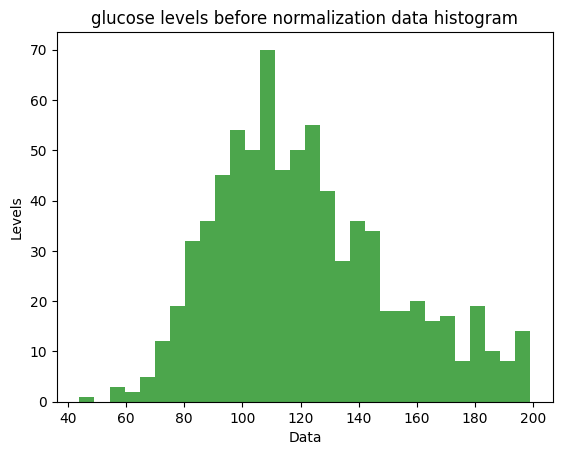

In [ ]:
datos = df['Glucose']  # Select only the 'Glucose' column
plt.hist(datos, bins=30, color='green', alpha=0.7)  # Draws the histogram
plt.title("glucose levels before normalization data histogram")  # Title
plt.xlabel("Data")  # Label for the x-axis
plt.ylabel("Levels")  # Label for the y-axis
plt.show()  # Shows the graph

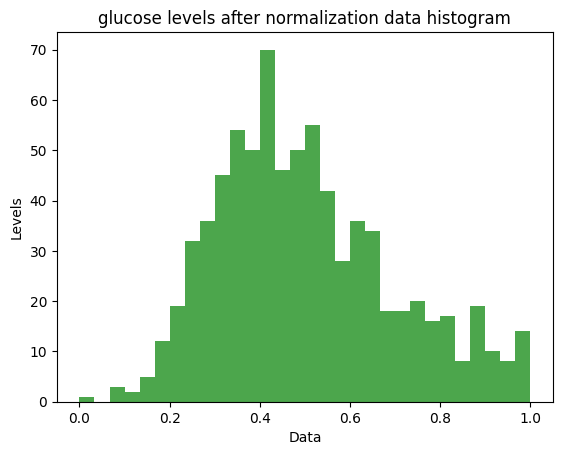

In [ ]:
datos = df_normalization['Glucose']  # Select only the 'Glucose' column
plt.hist(datos, bins=30, color='green', alpha=0.7)  # Draws the histogram
plt.title("glucose levels after normalization data histogram")  # Title
plt.xlabel("Data")  # Label for the x-axis
plt.ylabel("Levels")  # Label for the y-axis
plt.show()  # Shows the graph

In this case the code creates a side-by-side comparison of sine and cosine waves over the same interval (0–10), making it easy to visually compare their shapes and phase difference. It shows how to plot two related variables side by side for comparison.

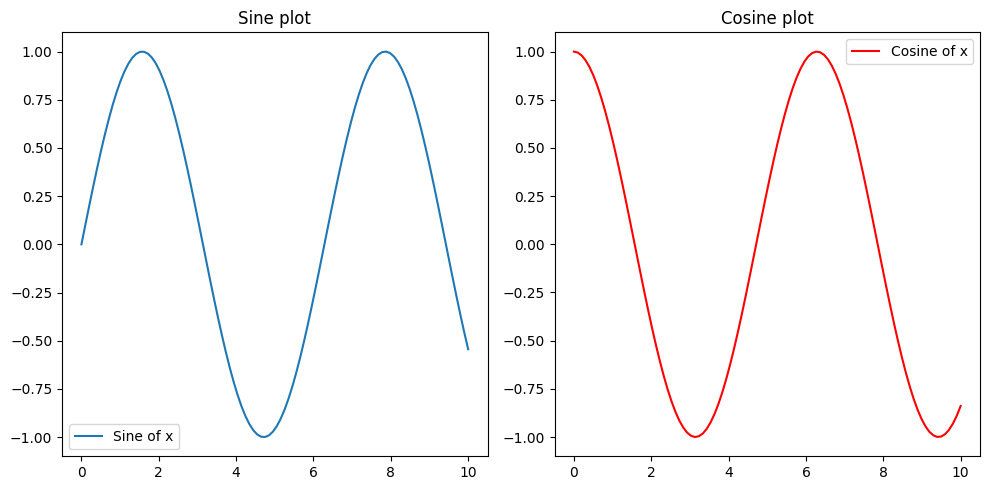

In [ ]:
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # Creates a row with two graphs/plots

axs[0].plot(x, y1, label="Sine of x")
axs[0].set_title("Sine plot")
axs[0].legend()

axs[1].plot(x, y2, label="Cosine of x", color='red')
axs[1].set_title("Cosine plot")
axs[1].legend()

plt.tight_layout()  # Adjusts the spacing
plt.show()  # Shows the graphs/plots

In this phase we create a boxplot of the BloodPressure column in the dataset to identify the distribution of blood pressure values and detect possible outliers.

*   plt.figure() → Opens a new figure so the plot is independent.
*   plt.boxplot(df['BloodPressure'], vert=False, patch_artist=True) → Draws the boxplot:

       *   df['BloodPressure'] → the column we want to analyze.
       *   vert=False → makes the boxplot horizontal instead of vertical.
       *   patch_artist=True → allows the box to be filled with color (if styles are added).

*   plt.xlabel("Blood Pressure") → Labels the x-axis.











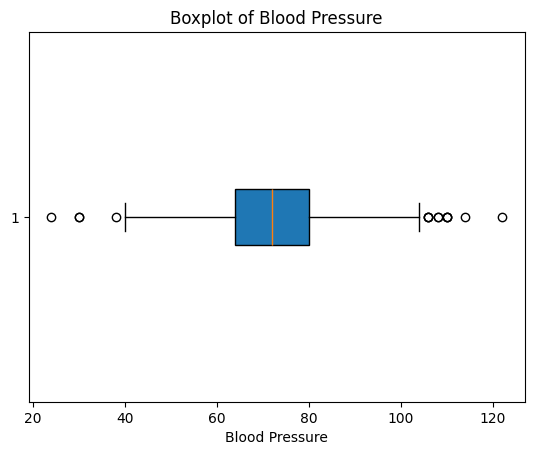

In [ ]:
# 2) Boxplot to identify outliers in Blood Pressure
plt.figure()
plt.boxplot(df['BloodPressure'], vert=False, patch_artist=True)
plt.title("Boxplot of Blood Pressure")
plt.xlabel("Blood Pressure")
plt.show()



---



First, the data was cleaned by removing the rows with missing values in the Glucose and BMI columns to avoid errors in the model. Then, the variables were defined: X contains the glucose values (independent variable) and Y the BMI values (dependent variable).

With these variables, a linear regression model (LinearRegression) was trained to fit a line that best represents the relationship between them. Afterwards, the predictions (y_pred) were calculated, and two elements were plotted: the real data as a red scatter plot and the fitted line in blue, visually showing the correlation between both variables.

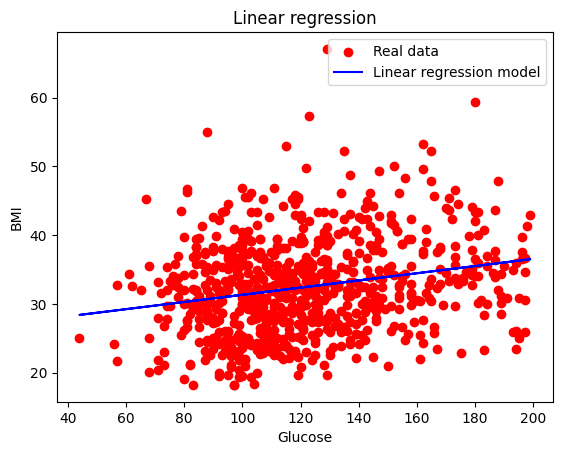

In [ ]:
# 3) Scatter plot between Glucose and BMI to analyze correlation
# Drop rows with NaN values before performing linear regression
df_cleaned = df.dropna(subset=['Glucose', 'BMI'])

X = df_cleaned[["Glucose"]].values
Y = df_cleaned [ ["BMI" ]]. values

model = LinearRegression()
model.fit(X,Y)

y_pred = model.predict(X)

plt.scatter(X,Y, color = "red", label="Real data" )
plt.plot(X, y_pred, color = "blue", label = "Linear regression model")
plt.title("Linear regression")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.legend()
plt. show()



---



Here, a bar chart was created to show how many patients have diabetes and how many do not, using the Outcome column of the dataset. First, value_counts() was applied to Outcome, which counts how many times each category appears (0 = no diabetes, 1 = diabetes). These counts were stored in Results.

Then, a bar chart (plt.bar) was generated using the indices of Results (0 and 1) on the x-axis and their corresponding values (the frequency of each category) on the y-axis. Two colors were used: red for “No diabetes” and green for “Diabetes.”

Finally, the chart was customized: the x-axis labels were changed with plt.xticks to show clear text instead of numbers, a label was added to the y-axis, a title was set, and the figure was displayed.

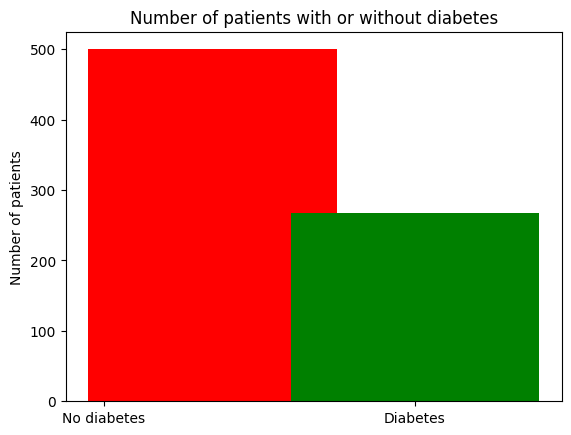

In [ ]:
# 4) Bar chart showing the number of patients with and without diabetes (Outcome)
Results = df["Outcome"].value_counts ()

plt.bar(Results.index, Results.values, color = ["red","green"])
plt.xticks([0,1], ["No diabetes", "Diabetes"])
plt.ylabel("Number of patients")
plt.title("Number of patients with or without diabetes")
plt. show()

In [ ]:
for column in df.columns:
  zero_count = (df[column] == 0).sum()
  print(f"Column '{column}': {zero_count} zeros")

Column 'Pregnancies': 0 zeros
Column 'Glucose': 0 zeros
Column 'BloodPressure': 0 zeros
Column 'SkinThickness': 0 zeros
Column 'Insulin': 0 zeros
Column 'BMI': 0 zeros
Column 'DiabetesPedigreeFunction': 0 zeros
Column 'Age': 0 zeros
Column 'Outcome': 0 zeros


# **PART 4**

**1.  What impact do missing values have on data analysis?**

*They reduce the quality and reliability of results, since missing values can bias measures like mean or variance if not handled properly. Removing records causes information loss and lowers statistical power, while ignoring them may lead to errors. Therefore, applying imputation or suitable strategies is essential to ensure trustworthy data analysis.*

**2.  How can we detect and handle outliers in biomedical datasets?**

*Outliers in biomedical data are detected using statistical methods such as the interquartile range or z-scores, and through visualizations like boxplots or scatterplots. They can be removed if they represent errors, replaced with representative values like the median, or transformed. However, if they reflect true biological variability, it is better to keep them and use robust analysis methods that are less affected by extremes.*

**3.  What are some common causes of missing or incorrect data in biomedical studies?**

*Common causes include human error in data entry, faulty sensors or devices during measurements, patients not following medical procedures, or incomplete records due to lost follow-ups. Additionally, some variables may be intentionally omitted to protect privacy. Understanding these causes helps determine whether missing data should be imputed, corrected, or excluded.*

**4.  How does normalizing data improve the performance of Machine Learning models?**

*Normalization ensures that all features are on the same scale, typically between 0 and 1, preventing attributes with larger ranges (like glucose levels) from dominating those with smaller ranges (like pedigree function). This improves the stability and convergence speed of algorithms, enhances model accuracy, and ensures fair treatment of all input variables.*

**5.  Why is visualizing data an important step before applying Machine Learning models?**

*Visualization reveals patterns, distributions, correlations, and anomalies in the dataset. It allows researchers to identify potential issues such as skewed data, outliers, or class imbalances before modeling. In biomedical contexts, visualization also makes complex data more interpretable for clinicians and stakeholders, bridging the gap between raw numbers and meaningful medical insights.*

**6.  Why is preprocessing critical when working with medical datasets?**

*Medical datasets often contain missing values, inconsistent entries, and variables with different scales. Preprocessing ensures data quality, consistency, and readiness for analysis. By cleaning, imputing, and normalizing, researchers reduce noise and prevent misleading results, which is crucial when patient outcomes and clinical decisions may depend on the model’s predictions.*

**7.  What ethical concerns should be considered when handling patient data?**

Ethical concerns include ensuring patient privacy, maintaining confidentiality, and complying with regulations such as HIPAA or GDPR. Researchers must also avoid introducing biases that could lead to discriminatory models, ensure transparency in how data is used, and obtain proper consent for data collection. Ultimately, protecting patients’ rights and trust is as important as the technical accuracy of the analysis.
